# Итоговый анализ NL2SQL

Ноутбук содержит итоговый анализ экспериментальных результатов в задаче `NL2SQL`. Его цель — проверить гипотезу о том, что специализированная компактная модель может обеспечивать качество генерации SQL, сопоставимое с качеством универсальной большой языковой модели, при другом вычислительном профиле.

Основная часть анализа опирается на сопоставимые результаты в режиме `EA`. Основной метрикой качества выступает `Execution Accuracy (EA)`. Дополнительные метрики — интегральная метрика вычислительной эффективности `Eff` и `Pass@K`. Метрика `Eff` нужна для оценки вычислительного профиля моделей, а `Pass@K` — для анализа поведения моделей в режиме многократной генерации.

## Содержание

1. Данные и воспроизводимость
2. Исследовательская постановка
3. Состав сравниваемых моделей
4. Распределение EA на уровне агрегированных результатов
5. Проверка гипотезы и оценка достижимого уровня качества
6. Парные сравнения на общем наборе задач
7. Структурные различия между Spider и BIRD
8. Интегральная метрика вычислительной эффективности и ее компоненты
9. Дополнительный контрольный mini-benchmark
10. Ограничения исследования
11. Приложение A: Дополнительные результаты EA
12. Приложение B: Pass@K
13. Итоговые выводы


## 1. Данные и воспроизводимость

В этом разделе загружаются итоговые артефакты экспериментов и фиксируется источник данных, на котором основан анализ. Ноутбук работает поверх уже рассчитанных результатов из `results/nl2sql` и воспроизводит итоговые таблицы и графики без повторного запуска инференса.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path
from typing import Any, cast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from nl2sql.notebooks.analysis_utils import (
    RESULTS_DIR,
    build_completeness_audit,
    compute_pairwise_ea_deltas,
    compute_sample_outcomes,
    filter_appendix_rows,
    filter_main_report_rows,
    get_expected_sample_counts,
    get_figures_dir,
    load_mini_bench_artifacts,
    load_records,
    load_summary_metrics,
    reset_analysis_caches,
)

sns.set_theme(style='whitegrid', context='talk')
pd.options.display.float_format = '{:.4f}'.format

RUN_LABEL = 'ea'
PASS_K_LABEL = 'pass_k'
EXPECTED_COUNTS = get_expected_sample_counts(RUN_LABEL)
FIGURES_DIR = get_figures_dir('final')
palette = {'m1': '#1b9e77', 'm2': '#d95f02'}
MINI_BENCH_EXPECTED_CASES = 50


## 2. Исследовательская постановка

В работе проверяется следующая гипотеза:

> специализированная компактная модель способна обеспечивать качество генерации SQL, сопоставимое с качеством большой универсальной модели, при ином профиле вычислительных затрат.

Основной метрикой качества в этом сравнении является `EA`, поскольку она показывает долю задач, в которых модель с первой попытки строит SQL-запрос, эквивалентный эталону по результату исполнения. Вычислительная эффективность рассматривается отдельно через интегральную метрику `Eff`, а `Pass@K` используется как вспомогательная характеристика режима многократной генерации. Эти метрики решают разные задачи и не подменяют друг друга.

## 3. Состав сравниваемых моделей

Перед сравнительным анализом фиксируется состав сопоставимого корпуса результатов. В основную часть исследования включаются только модели, для которых доступны сопоставимые значения `EA` на бенчмарках `Spider` и `BIRD`. Это делает межмодельное сравнение корректным.

Итоговый вывод строится по единому набору задач, на котором все сравниваемые модели наблюдаются в одинаковых условиях.

In [2]:
reset_analysis_caches()
ea_samples_df, ea_generations_df = load_records(RUN_LABEL)
ea_summary_df = cast(Any, load_summary_metrics(RUN_LABEL).copy())
ea_outcomes_df = cast(Any, compute_sample_outcomes(RUN_LABEL).copy())
ea_audit_df = cast(Any, build_completeness_audit(RUN_LABEL, summary_df=ea_summary_df, expected_counts=EXPECTED_COUNTS))
main_ea_df = cast(Any, filter_main_report_rows(ea_summary_df, run_label=RUN_LABEL, audit_df=ea_audit_df))
appendix_ea_df = cast(Any, filter_appendix_rows(ea_summary_df, run_label=RUN_LABEL, audit_df=ea_audit_df))
main_model_names = sorted(main_ea_df['model_name'].unique().tolist())
appendix_model_names = sorted(appendix_ea_df['model_name'].unique().tolist())

display(Markdown(f'**Источник данных и артефактов:** `{RESULTS_DIR}`'))

comparison_view = ea_audit_df[[
    'model_display_name',
    'model_family',
    'spider_n_samples',
    'bird_n_samples',
    'is_complete',
]].copy()
comparison_view = comparison_view[comparison_view['model_display_name'].isin(set(main_ea_df['model_display_name']))].rename(columns={
    'model_display_name': 'Модель',
    'model_family': 'Класс модели',
    'spider_n_samples': 'Число задач Spider',
    'bird_n_samples': 'Число задач BIRD',
    'is_complete': 'Включена в сравнение',
})
display(Markdown('**Таблица 1. Состав моделей, включенных в основное сравнение**'))
display(comparison_view.sort_values(['Класс модели', 'Модель']).reset_index(drop=True))
display(Markdown(f'**Модели, включенные в основное сравнение:** {sorted(main_ea_df["model_display_name"].unique().tolist())}'))
if appendix_model_names:
    display(Markdown('Дополнительные результаты приведены в приложении A.'))

**Источник данных и артефактов:** `/home/count/code/vkr/results/nl2sql`

**Таблица 1. Состав моделей, включенных в основное сравнение**

,Модель,Класс модели,Число задач Spider,Число задач BIRD,Включена в сравнение
0,ChatGPT 5.2,m1,1034,1534,True
1,DeepSeek V3.2,m1,1034,1534,True
2,Arctic-Text2SQL-R1-7B,m2,1034,1534,True
3,Defog-Llama3-SQLCoder-8B q4_0,m2,1034,1534,True
4,Hrida-T2SQL q8_0,m2,1034,1534,True


**Модели, включенные в основное сравнение:** ['Arctic-Text2SQL-R1-7B', 'ChatGPT 5.2', 'DeepSeek V3.2', 'Defog-Llama3-SQLCoder-8B q4_0', 'Hrida-T2SQL q8_0']

Дополнительные результаты приведены в приложении A.

## 4. Распределение `EA` на уровне агрегированных результатов

Для каждой модели рассматривается не только среднее значение `EA`, но и bootstrap-оценка распределения агрегированной метрики через квантили `q05`, `q50` и `q95`. Такой способ представления дает не одну точку, а интервал значений и делает последующий сравнительный вывод более надежным.

In [3]:
ea_view_cols = [
    'model_display_name', 'model_family', 'benchmark', 'n_samples',
    'execution_accuracy', 'execution_accuracy_q05', 'execution_accuracy_q50', 'execution_accuracy_q95',
]
ea_view_df = main_ea_df[ea_view_cols].sort_values(['benchmark', 'model_family', 'execution_accuracy'], ascending=[True, True, False])
ea_view_display = ea_view_df.rename(columns={
    'model_display_name': 'Модель',
    'model_family': 'Класс модели',
    'benchmark': 'Бенчмарк',
    'n_samples': 'Число задач',
    'execution_accuracy': 'EA',
    'execution_accuracy_q05': 'EA q05',
    'execution_accuracy_q50': 'EA q50',
    'execution_accuracy_q95': 'EA q95',
})
display(Markdown('**Таблица 2. Основные значения `EA` и bootstrap-квантили для сопоставимого набора моделей**'))
display(ea_view_display.round(4))

**Таблица 2. Основные значения `EA` и bootstrap-квантили для сопоставимого набора моделей**

,Модель,Класс модели,Бенчмарк,Число задач,EA,EA q05,EA q50,EA q95
0,ChatGPT 5.2,m1,bird,1534,0.3657,0.3468,0.3657,0.3853
1,DeepSeek V3.2,m1,bird,1534,0.3227,0.3031,0.3227,0.3422
2,Arctic-Text2SQL-R1-7B,m2,bird,1534,0.5378,0.5150,0.5381,0.5593
3,Defog-Llama3-SQLCoder-8B q4_0,m2,bird,1534,0.2634,0.2458,0.2634,0.2823
4,Hrida-T2SQL q8_0,m2,bird,1534,0.1551,0.1402,0.1551,0.1701
5,ChatGPT 5.2,m1,spider,1034,0.7427,0.7195,0.7427,0.7650
6,DeepSeek V3.2,m1,spider,1034,0.7369,0.7147,0.7369,0.7592
7,Arctic-Text2SQL-R1-7B,m2,spider,1034,0.7718,0.7495,0.7718,0.7921
8,Defog-Llama3-SQLCoder-8B q4_0,m2,spider,1034,0.5629,0.5387,0.5629,0.5880
9,Hrida-T2SQL q8_0,m2,spider,1034,0.4913,0.4652,0.4913,0.5155


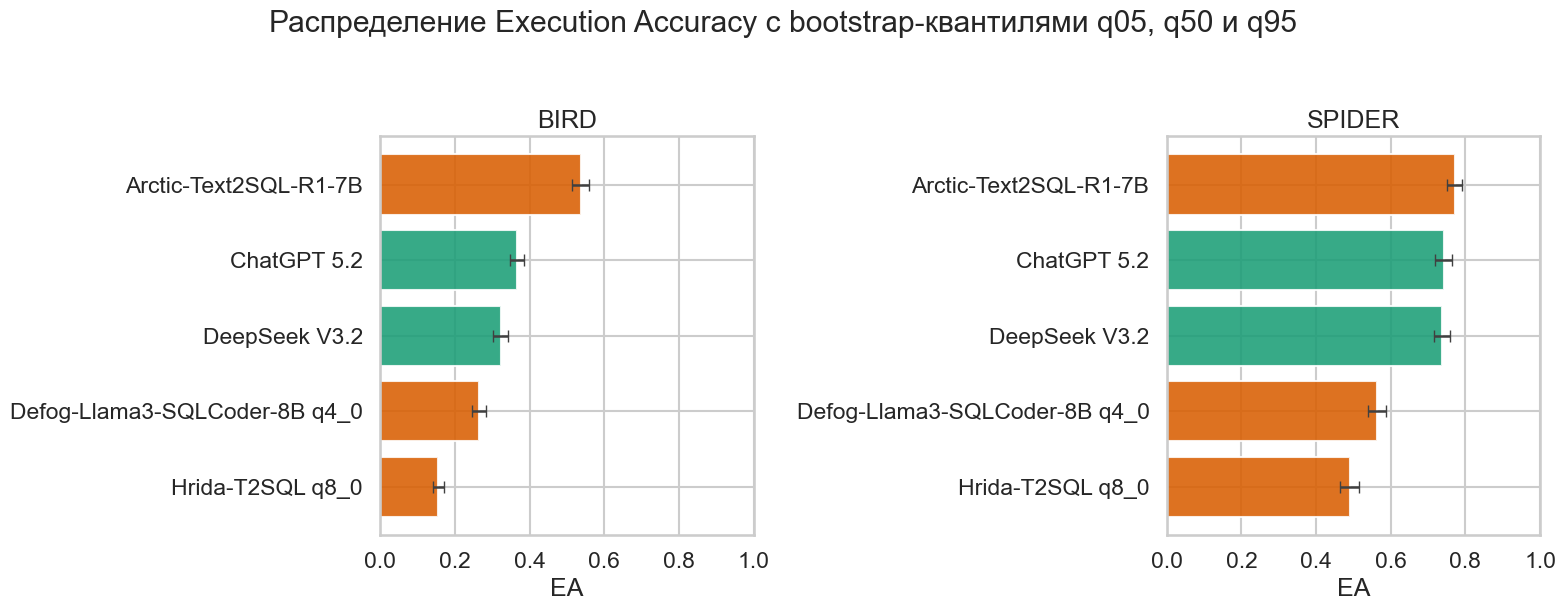

In [4]:
benchmarks = list(ea_view_df['benchmark'].dropna().unique())
fig, axes = plt.subplots(1, len(benchmarks), figsize=(8 * max(len(benchmarks), 1), 6), sharex=False)
if len(benchmarks) == 1:
    axes = [axes]
for ax, benchmark in zip(axes, benchmarks):
    subset = ea_view_df[ea_view_df['benchmark'] == benchmark].sort_values('execution_accuracy')
    y = np.arange(len(subset))
    x = subset['execution_accuracy'].to_numpy()
    lower = x - subset['execution_accuracy_q05'].to_numpy()
    upper = subset['execution_accuracy_q95'].to_numpy() - x
    colors = subset['model_family'].map(palette).tolist()
    ax.barh(y, x, color=colors, alpha=0.88)
    ax.errorbar(x, y, xerr=np.vstack([lower, upper]), fmt='none', ecolor='0.25', capsize=4, linewidth=1.8)
    ax.set_yticks(y)
    ax.set_yticklabels(subset['model_display_name'])
    ax.set_xlim(0, 1)
    ax.set_title(benchmark.upper())
    ax.set_xlabel('EA')
fig.suptitle('Распределение Execution Accuracy с bootstrap-квантилями q05, q50 и q95', y=1.03)
fig.tight_layout()
plt.show()


Визуализация показывает, что различия между моделями устойчиво воспроизводятся на обоих бенчмарках, но их масштаб заметно зависит от сложности набора. Уже здесь видно, что `Spider` и `BIRD` дают разную картину сравнения: на `Spider` значения `EA` в целом выше, а на `BIRD` интервалы смещены вниз для всех моделей.

## 5. Проверка гипотезы и оценка достижимого уровня качества

В этом разделе результаты `EA` интерпретируются в логике проверяемой гипотезы: оценивается, можно ли считать качество специализированных компактных моделей сопоставимым с качеством больших универсальных моделей на `Spider` и `BIRD`, и при каких условиях это утверждение сохраняется.

Сначала рассматриваются лучшие представители классов `M1` и `M2`, после чего отдельно оценивается, достигают ли они уровня качества, близкого к диапазону `EA = 0.8-0.9`.

In [5]:
best_by_family_df = cast(Any, (
    main_ea_df.sort_values(['benchmark', 'model_family', 'execution_accuracy'], ascending=[True, True, False])
    .groupby(['benchmark', 'model_family'], as_index=False)
    .first()
))
best_by_family_df['delta_to_other_family'] = np.nan
for benchmark in sorted(best_by_family_df['benchmark'].unique()):
    subset = best_by_family_df[best_by_family_df['benchmark'] == benchmark].set_index('model_family')
    if {'m1', 'm2'}.issubset(subset.index):
        best_by_family_df.loc[(best_by_family_df['benchmark'] == benchmark) & (best_by_family_df['model_family'] == 'm2'), 'delta_to_other_family'] = subset.loc['m2', 'execution_accuracy'] - subset.loc['m1', 'execution_accuracy']
        best_by_family_df.loc[(best_by_family_df['benchmark'] == benchmark) & (best_by_family_df['model_family'] == 'm1'), 'delta_to_other_family'] = subset.loc['m1', 'execution_accuracy'] - subset.loc['m2', 'execution_accuracy']

best_by_family_view = best_by_family_df[['benchmark', 'model_family', 'model_display_name', 'execution_accuracy', 'execution_accuracy_q05', 'execution_accuracy_q95', 'delta_to_other_family']].copy()
best_by_family_view = best_by_family_view.rename(columns={
    'benchmark': 'Бенчмарк',
    'model_family': 'Класс модели',
    'model_display_name': 'Лучшая модель в классе',
    'execution_accuracy': 'EA',
    'execution_accuracy_q05': 'EA q05',
    'execution_accuracy_q95': 'EA q95',
    'delta_to_other_family': 'Разность EA с другим классом',
})
display(Markdown('**Таблица 3. Лучшие представители классов `M1` и `M2` по метрике `EA`**'))
display(best_by_family_view.round(4))

**Таблица 3. Лучшие представители классов `M1` и `M2` по метрике `EA`**

,Бенчмарк,Класс модели,Лучшая модель в классе,EA,EA q05,EA q95,Разность EA с другим классом
0,bird,m1,ChatGPT 5.2,0.3657,0.3468,0.3853,-0.1721
1,bird,m2,Arctic-Text2SQL-R1-7B,0.5378,0.5150,0.5593,0.1721
2,spider,m1,ChatGPT 5.2,0.7427,0.7195,0.7650,-0.0290
3,spider,m2,Arctic-Text2SQL-R1-7B,0.7718,0.7495,0.7921,0.0290


In [6]:
target_rows = []
for benchmark, subset in best_by_family_df.groupby('benchmark'):
    for family in ['m1', 'm2']:
        row = subset[subset['model_family'] == family].iloc[0]
        target_rows.append({
            'Бенчмарк': benchmark,
            'Класс модели': family,
            'Лучшая модель': row['model_display_name'],
            'EA': row['execution_accuracy'],
            'Попадание в диапазон 0.8-0.9': bool(0.8 <= row['execution_accuracy'] <= 0.9),
        })
target_df = pd.DataFrame(target_rows)
display(Markdown('**Таблица 4. Проверка достижения диапазона `EA = 0.8-0.9`**'))
display(target_df)

**Таблица 4. Проверка достижения диапазона `EA = 0.8-0.9`**

,Бенчмарк,Класс модели,Лучшая модель,EA,Попадание в диапазон 0.8-0.9
0,bird,m1,ChatGPT 5.2,0.3657,False
1,bird,m2,Arctic-Text2SQL-R1-7B,0.5378,False
2,spider,m1,ChatGPT 5.2,0.7427,False
3,spider,m2,Arctic-Text2SQL-R1-7B,0.7718,False


Сопоставление лучших представителей классов `M1` и `M2` показывает, что вопрос о сопоставимости качества нельзя решать без учета конкретного бенчмарка. На `Spider` различие между сильнейшими представителями классов невелико, тогда как на `BIRD` преимущество специализированной модели выражено заметно сильнее. Одновременно проверка диапазона `EA = 0.8-0.9` показывает, что ни один из рассматриваемых кандидатов не достигает этого уровня на полном наборе задач.

## 6. Парные сравнения на общем наборе задач

Чтобы не ограничиваться сравнением агрегированных средних, далее рассчитывается `ΔEA` на одних и тех же задачах для каждой пары моделей. Такой анализ позволяет оценить не только величину различия, но и его устойчивость на общем наборе наблюдений.

In [7]:
pairwise_df = cast(Any, compute_pairwise_ea_deltas(RUN_LABEL, outcomes_df=ea_outcomes_df, allowed_models=main_model_names))
pairwise_view = pairwise_df[['benchmark', 'comparison', 'matched_samples', 'left_ea', 'right_ea', 'delta_ea', 'delta_ea_q05', 'delta_ea_q50', 'delta_ea_q95']].copy()
pairwise_view = pairwise_view.rename(columns={
    'benchmark': 'Бенчмарк',
    'comparison': 'Сравнение моделей',
    'matched_samples': 'Число общих задач',
    'left_ea': 'EA модели A',
    'right_ea': 'EA модели B',
    'delta_ea': 'ΔEA',
    'delta_ea_q05': 'ΔEA q05',
    'delta_ea_q50': 'ΔEA q50',
    'delta_ea_q95': 'ΔEA q95',
})
display(Markdown('**Таблица 5. Парные различия `EA` на общем наборе задач**'))
display(pairwise_view.round(4))

**Таблица 5. Парные различия `EA` на общем наборе задач**

,Бенчмарк,Сравнение моделей,Число общих задач,EA модели A,EA модели B,ΔEA,ΔEA q05,ΔEA q50,ΔEA q95
0,bird,Arctic-Text2SQL-R1-7B vs Hrida-T2SQL q8_0,1534,0.5378,0.1551,0.3827,0.3605,0.3823,0.4036
1,bird,Arctic-Text2SQL-R1-7B vs Defog-Llama3-SQLCoder...,1534,0.5378,0.2634,0.2744,0.2510,0.2744,0.2979
2,bird,Arctic-Text2SQL-R1-7B vs DeepSeek V3.2,1534,0.5378,0.3227,0.2151,0.1923,0.2138,0.2360
3,bird,ChatGPT 5.2 vs Hrida-T2SQL q8_0,1534,0.3657,0.1551,0.2106,0.1890,0.2112,0.2353
4,bird,Arctic-Text2SQL-R1-7B vs ChatGPT 5.2,1534,0.5378,0.3657,0.1721,0.1486,0.1708,0.1943
5,bird,DeepSeek V3.2 vs Hrida-T2SQL q8_0,1534,0.3227,0.1551,0.1675,0.1454,0.1682,0.1910
6,bird,Defog-Llama3-SQLCoder-8B q4_0 vs Hrida-T2SQL q8_0,1534,0.2634,0.1551,0.1082,0.0893,0.1082,0.1271
7,bird,ChatGPT 5.2 vs Defog-Llama3-SQLCoder-8B q4_0,1534,0.3657,0.2634,0.1023,0.0808,0.1030,0.1258
8,bird,DeepSeek V3.2 vs Defog-Llama3-SQLCoder-8B q4_0,1534,0.3227,0.2634,0.0593,0.0384,0.0593,0.0854
9,bird,ChatGPT 5.2 vs DeepSeek V3.2,1534,0.3657,0.3227,0.0430,0.0274,0.0430,0.0600


Парные сравнения уточняют вывод по средним значениям: различия между моделями возникают не из-за нескольких отдельных выбросов, а сохраняются на общем наборе задач. Это особенно важно для `BIRD`, где преимущество сильнейшей специализированной модели относительно лучших `M1` выглядит устойчивым, а не случайным.

## 7. Структурные различия между Spider и BIRD

Оценивать сопоставимость качества только по `Spider` недостаточно. `Spider` и `BIRD` различаются не только формально, но и содержательно: на более реалистичном и сложном бенчмарке поведение моделей меняется, и именно это задает границы применимости итогового вывода.

In [8]:
main_outcomes_df = cast(Any, ea_outcomes_df[ea_outcomes_df['model_name'].isin(main_model_names)].copy())

def categorize_error(row: pd.Series) -> str:
    if bool(row['first_hit']):
        return 'correct'
    if bool(row.get('empty_sql', False)):
        return 'empty_sql'
    if not bool(row.get('first_pred_success', False)):
        return 'execution_error'
    return 'wrong_result'

main_outcomes_df['error_type'] = main_outcomes_df.apply(categorize_error, axis=1)

difficulty_df = (
    main_outcomes_df.dropna(subset=['difficulty'])
    .groupby(['benchmark', 'difficulty'], as_index=False)['first_hit']
    .mean()
    .rename(columns={'first_hit': 'ea'})
)
main_outcomes_df['question_len_bucket'] = pd.qcut(main_outcomes_df['question_len'], q=4, duplicates='drop')
question_len_df = (
    main_outcomes_df.groupby(['benchmark', 'question_len_bucket'], as_index=False, observed=False)['first_hit']
    .mean()
    .rename(columns={'first_hit': 'ea'})
)
error_mix_df = (
    main_outcomes_df.groupby(['benchmark', 'error_type']).size().rename('count').reset_index()
)
error_mix_df['share'] = error_mix_df['count'] / error_mix_df.groupby('benchmark')['count'].transform('sum')

difficulty_view = difficulty_df.rename(columns={
    'benchmark': 'Бенчмарк',
    'difficulty': 'Уровень сложности',
    'ea': 'EA',
})
question_len_view = question_len_df.rename(columns={
    'benchmark': 'Бенчмарк',
    'question_len_bucket': 'Интервал длины вопроса',
    'ea': 'EA',
})
error_mix_view = error_mix_df[['benchmark', 'error_type', 'share']].copy()
error_mix_view['error_type'] = error_mix_view['error_type'].map({
    'correct': 'Корректный результат',
    'execution_error': 'Ошибка выполнения',
    'empty_sql': 'Пустой SQL',
    'wrong_result': 'Некорректный результат',
}).fillna(error_mix_view['error_type'])
error_mix_view = error_mix_view.rename(columns={
    'benchmark': 'Бенчмарк',
    'error_type': 'Тип исхода',
    'share': 'Доля',
})

display(Markdown('**Таблица 6. `EA` по уровням сложности**'))
display(difficulty_view.round(4))
display(Markdown('**Таблица 7. `EA` по интервалам длины вопроса**'))
display(question_len_view.round(4))
display(Markdown('**Таблица 8. Структура исходов выполнения**'))
display(error_mix_view.round(4))

**Таблица 6. `EA` по уровням сложности**

,Бенчмарк,Уровень сложности,EA
0,bird,challenging,0.2028
1,bird,moderate,0.2259
2,bird,simple,0.4004


**Таблица 7. `EA` по интервалам длины вопроса**

,Бенчмарк,Интервал длины вопроса,EA
0,bird,"(17.999, 56.0]",0.4800
1,bird,"(56.0, 72.0]",0.3485
2,bird,"(72.0, 92.0]",0.3010
3,bird,"(92.0, 286.0]",0.2416
4,spider,"(17.999, 56.0]",0.7587
5,spider,"(56.0, 72.0]",0.6878
6,spider,"(72.0, 92.0]",0.5831
7,spider,"(92.0, 286.0]",0.5007


**Таблица 8. Структура исходов выполнения**

,Бенчмарк,Тип исхода,Доля
0,bird,Корректный результат,0.3289
1,bird,Ошибка выполнения,0.1807
2,bird,Некорректный результат,0.4904
3,spider,Корректный результат,0.6611
4,spider,Ошибка выполнения,0.0603
5,spider,Некорректный результат,0.2785


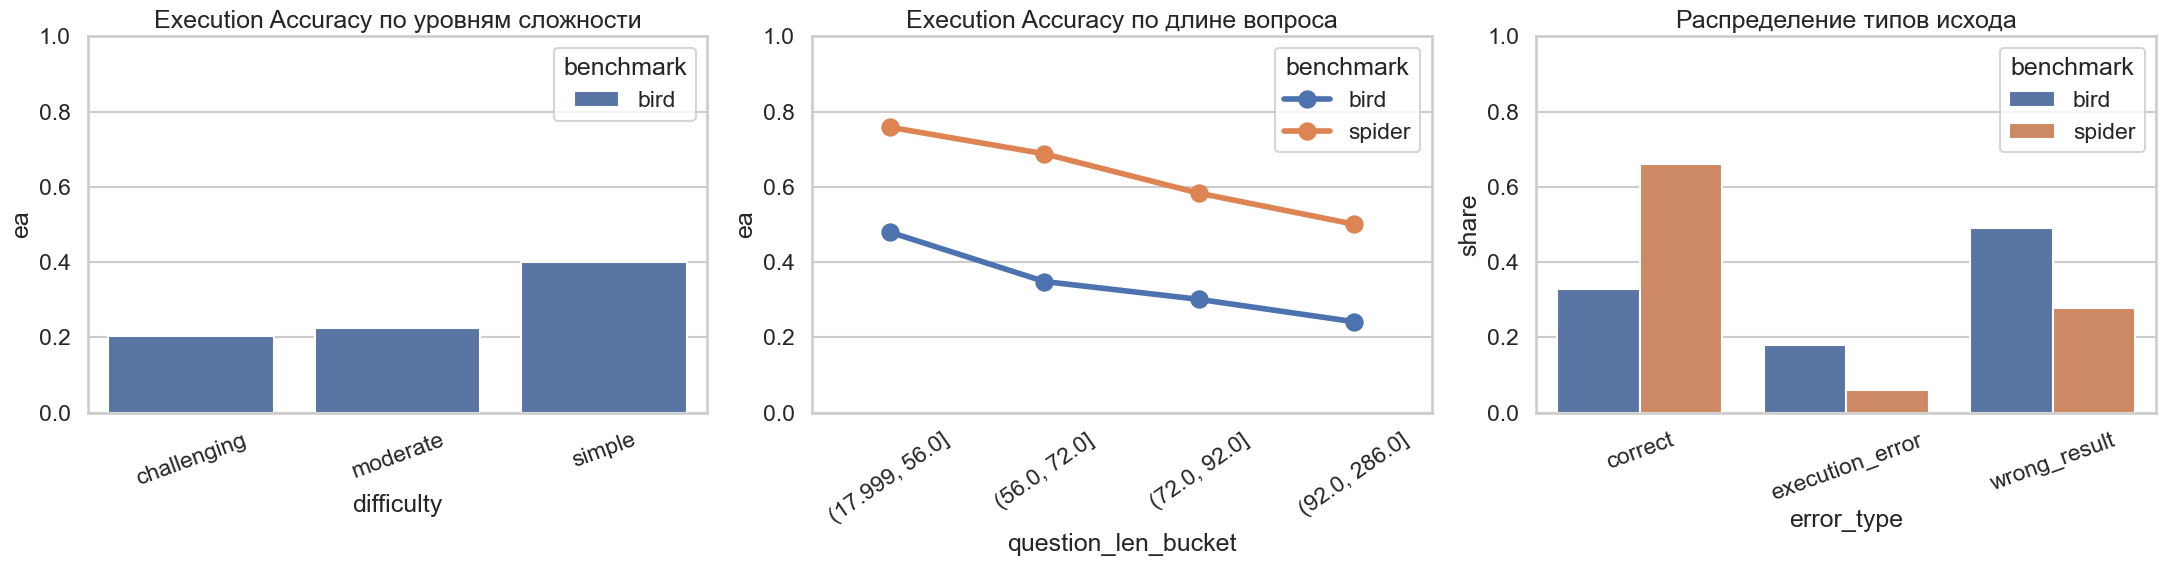

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
sns.barplot(data=difficulty_df, x='difficulty', y='ea', hue='benchmark', ax=axes[0])
axes[0].set_title('Execution Accuracy по уровням сложности')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=20)

sns.pointplot(data=question_len_df, x='question_len_bucket', y='ea', hue='benchmark', ax=axes[1])
axes[1].set_title('Execution Accuracy по длине вопроса')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=35)

sns.barplot(data=error_mix_df, x='error_type', y='share', hue='benchmark', ax=axes[2])
axes[2].set_title('Распределение типов исхода')
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=20)

fig.tight_layout()
plt.show()


Стратифицированный анализ показывает, что снижение качества на `BIRD` связано не только с общим усложнением бенчмарка, но и с изменением структуры ошибок. По мере роста сложности и длины вопроса `EA` падает на обоих наборах, однако на `BIRD` заметно возрастает доля исходов типа `wrong_result`. Это говорит о более трудном переходе от синтаксически исполнимого запроса к семантически корректному результату.

## 8. Интегральная метрика вычислительной эффективности и ее компоненты

В этой работе вычислительная эффективность задается интегральной метрикой `Eff`, которая агрегирует ключевые характеристики вычислительного профиля модели. В текущей версии методики `Eff` рассчитывается на основе времени инференса, числа токенов и стоимости генерации.

Поэтому время инференса, число токенов и стоимость выступают не как конкурирующие метрики того же уровня, а как составляющие `Eff`. В основном тексте сначала показывается сама интегральная метрика, а затем — ее компоненты.

**Таблица 9. Интегральная метрика вычислительной эффективности**

,Модель,Бенчмарк,Интегральная метрика Eff,Нормализованная метрика Eff
2,Arctic-Text2SQL-R1-7B,bird,2212.0469,0.1090
0,ChatGPT 5.2,bird,1018.7061,0.1841
1,DeepSeek V3.2,bird,1363.8088,0.0903
3,Defog-Llama3-SQLCoder-8B q4_0,bird,512.2317,0.0475
4,Hrida-T2SQL q8_0,bird,756.4924,0.0888
7,Arctic-Text2SQL-R1-7B,spider,1676.6640,0.0515
5,ChatGPT 5.2,spider,712.3802,0.0755
6,DeepSeek V3.2,spider,1044.1776,0.0319
8,Defog-Llama3-SQLCoder-8B q4_0,spider,287.3931,0.0003
9,Hrida-T2SQL q8_0,spider,346.2196,0.0203


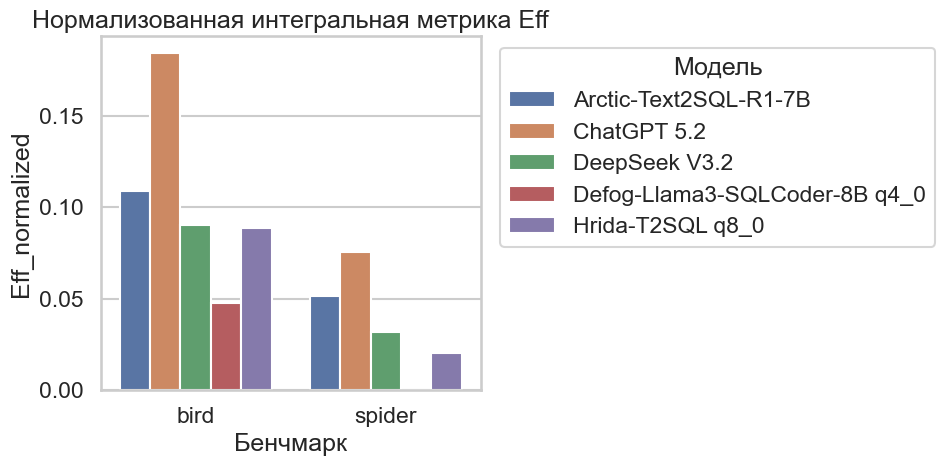

**Таблица 10. Компоненты интегральной метрики `Eff`**

,Модель,Бенчмарк,"Среднее время инференса, мс",Среднее число токенов,"Средняя стоимость, USD"
2,Arctic-Text2SQL-R1-7B,bird,6038.1180,1335.3716,0.0000
0,ChatGPT 5.2,bird,2374.4675,1021.2171,0.0019
1,DeepSeek V3.2,bird,3494.5106,1051.5183,0.0003
3,Defog-Llama3-SQLCoder-8B q4_0,bird,733.3158,974.1232,0.0000
4,Hrida-T2SQL q8_0,bird,1081.1594,1440.4817,0.0000
7,Arctic-Text2SQL-R1-7B,spider,4854.2380,734.6422,0.0000
5,ChatGPT 5.2,spider,1895.3430,479.2563,0.0009
6,DeepSeek V3.2,spider,2965.6751,514.9168,0.0002
8,Defog-Llama3-SQLCoder-8B q4_0,spider,531.0612,426.9159,0.0000
9,Hrida-T2SQL q8_0,spider,485.6148,668.4507,0.0000


**Таблица 11. Корреляция компонент интегральной метрики `Eff`**

,"Среднее время инференса, мс",Среднее число токенов,"Средняя стоимость, USD"
"Среднее время инференса, мс",1.0000,0.3020,-0.0240
Среднее число токенов,0.3020,1.0000,-0.0360
"Средняя стоимость, USD",-0.0240,-0.0360,1.0000


In [10]:
secondary_cols = ['model_display_name', 'benchmark', 'Eff', 'Eff_normalized', 'Tinf', 'Tok', 'Cost']
secondary_df = cast(Any, main_ea_df[secondary_cols].copy())
secondary_df = secondary_df.sort_values(['benchmark', 'model_display_name'])

eff_view = secondary_df[['model_display_name', 'benchmark', 'Eff', 'Eff_normalized']].copy().rename(columns={
    'model_display_name': 'Модель',
    'benchmark': 'Бенчмарк',
    'Eff': 'Интегральная метрика Eff',
    'Eff_normalized': 'Нормализованная метрика Eff',
})
display(Markdown('**Таблица 9. Интегральная метрика вычислительной эффективности**'))
display(eff_view.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=secondary_df,
    x='benchmark',
    y='Eff_normalized',
    hue='model_display_name',
    ax=ax,
)
ax.set_title('Нормализованная интегральная метрика Eff')
ax.set_xlabel('Бенчмарк')
ax.set_ylabel('Eff_normalized')
ax.legend(title='Модель', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
plt.show()

component_view = secondary_df[['model_display_name', 'benchmark', 'Tinf', 'Tok', 'Cost']].copy().rename(columns={
    'model_display_name': 'Модель',
    'benchmark': 'Бенчмарк',
    'Tinf': 'Среднее время инференса, мс',
    'Tok': 'Среднее число токенов',
    'Cost': 'Средняя стоимость, USD',
})
display(Markdown('**Таблица 10. Компоненты интегральной метрики `Eff`**'))
display(component_view.round(4))

secondary_corr = secondary_df[['Tinf', 'Tok', 'Cost']].apply(pd.to_numeric, errors='coerce').corr()
secondary_corr_view = secondary_corr.rename(index={
    'Tinf': 'Среднее время инференса, мс',
    'Tok': 'Среднее число токенов',
    'Cost': 'Средняя стоимость, USD',
}, columns={
    'Tinf': 'Среднее время инференса, мс',
    'Tok': 'Среднее число токенов',
    'Cost': 'Средняя стоимость, USD',
})
display(Markdown('**Таблица 11. Корреляция компонент интегральной метрики `Eff`**'))
display(secondary_corr_view.round(3))

Раздел эффективности стоит читать как отдельное измерение сравнения: он не меняет вывода по качеству, а уточняет, каким вычислительным профилем достигается наблюдаемый `EA`. Метрика `Eff` удобна для компактного сопоставления, а таблица компонент помогает понять, за счет каких факторов складываются различия между моделями.

## 9. Дополнительный контрольный mini-benchmark

Этот раздел добавляет небольшой локальный контрольный эксперимент к основному сравнению на `Spider` и `BIRD`. Его задача не в том, чтобы заменить общепринятые бенчмарки, а в том, чтобы показать, как лучшие представители `M1` и `M2` ведут себя на компактном, полностью контролируемом наборе business-like задач при том же базовом NL2SQL-контуре.


In [ ]:
family_leaders = (
    main_ea_df.groupby(['model_family', 'model_key', 'model_display_name'], as_index=False)['execution_accuracy']
    .mean()
    .sort_values(['model_family', 'execution_accuracy'], ascending=[True, False])
    .groupby('model_family', as_index=False)
    .first()
)
mini_target_keys = [key for key in family_leaders['model_key'].dropna().tolist() if key]
mini_target_names = family_leaders['model_display_name'].dropna().tolist()

mini_summary_df, mini_category_df, mini_difficulty_df, mini_failure_df = load_mini_bench_artifacts(
    model_keys=mini_target_keys,
)
mini_summary_complete_df = mini_summary_df[mini_summary_df['n_cases'] == MINI_BENCH_EXPECTED_CASES].copy()
mini_available_keys = mini_summary_complete_df['model_key'].dropna().tolist()
mini_category_complete_df = mini_category_df[mini_category_df['model_key'].isin(mini_available_keys)].copy()
mini_difficulty_complete_df = mini_difficulty_df[mini_difficulty_df['model_key'].isin(mini_available_keys)].copy()
mini_failure_complete_df = mini_failure_df[mini_failure_df['model_key'].isin(mini_available_keys)].copy()

leaders_text = ', '.join(mini_target_names) if mini_target_names else 'лучших представителей M1 и M2'
display(Markdown(f'**Контрольный набор анализируется только для моделей:** {leaders_text}.'))

if not mini_summary_complete_df.empty:
    mini_summary_view = mini_summary_complete_df[[
        'model_display_name', 'model_family', 'n_cases', 'execution_accuracy', 'execution_success_rate', 'model_latency_ms', 'prompt_profile'
    ]].copy().rename(columns={
        'model_display_name': 'Модель',
        'model_family': 'Класс модели',
        'n_cases': 'Число задач',
        'execution_accuracy': 'EA',
        'execution_success_rate': 'Доля исполнимых запросов',
        'model_latency_ms': 'Среднее время инференса, мс',
        'prompt_profile': 'Профиль prompt-а',
    })
    display(Markdown('**Таблица 12. Итог mini-benchmark для лучших представителей M1 и M2**'))
    display(mini_summary_view.sort_values(['Класс модели', 'Модель']).reset_index(drop=True).round(4))

    if not mini_category_complete_df.empty or not mini_difficulty_complete_df.empty:
        fig, axes = plt.subplots(1, 2, figsize=(18, 5))
        if not mini_category_complete_df.empty:
            sns.barplot(
                data=mini_category_complete_df,
                x='category',
                y='execution_accuracy',
                hue='model_display_name',
                ax=axes[0],
            )
            axes[0].set_title('Execution Accuracy по категориям mini-benchmark')
            axes[0].set_xlabel('Категория')
            axes[0].set_ylabel('EA')
            axes[0].set_ylim(0, 1)
            axes[0].tick_params(axis='x', rotation=35)
            axes[0].legend(title='Модель')
        else:
            axes[0].axis('off')

        if not mini_difficulty_complete_df.empty:
            sns.barplot(
                data=mini_difficulty_complete_df,
                x='difficulty',
                y='execution_accuracy',
                hue='model_display_name',
                ax=axes[1],
            )
            axes[1].set_title('Execution Accuracy по уровням сложности mini-benchmark')
            axes[1].set_xlabel('Сложность')
            axes[1].set_ylabel('EA')
            axes[1].set_ylim(0, 1)
            axes[1].tick_params(axis='x', rotation=20)
            axes[1].legend(title='Модель')
        else:
            axes[1].axis('off')

        fig.tight_layout()
        plt.show()

    if not mini_failure_complete_df.empty:
        failure_view = mini_failure_complete_df[[
            'model_display_name', 'case_id', 'category', 'difficulty', 'question', 'generated_sql', 'error_type'
        ]].copy().rename(columns={
            'model_display_name': 'Модель',
            'case_id': 'Кейс',
            'category': 'Категория',
            'difficulty': 'Сложность',
            'question': 'Вопрос',
            'generated_sql': 'Сгенерированный SQL',
            'error_type': 'Тип ошибки',
        })
        display(Markdown('**Таблица 13. Примеры характерных ошибок mini-benchmark**'))
        display(failure_view.head(5).reset_index(drop=True))

    if mini_summary_complete_df['model_family'].nunique() == 2:
        family_compare = (
            mini_summary_complete_df[['model_family', 'execution_accuracy']]
            .dropna()
            .drop_duplicates(subset=['model_family'])
            .set_index('model_family')['execution_accuracy']
            .to_dict()
        )
        m1_ea = family_compare.get('m1')
        m2_ea = family_compare.get('m2')
        if m1_ea is not None and m2_ea is not None:
            delta = m2_ea - m1_ea
            relation = 'выше' if delta > 0 else 'ниже' if delta < 0 else 'на том же уровне, что и'
            if relation == 'на том же уровне, что и':
                display(Markdown(
                    f'На контрольном наборе `EA` лучшего представителя `M2` находится {relation} лучший результат `M1`.'
                ))
            else:
                display(Markdown(
                    f'На контрольном наборе `EA` лучшего представителя `M2` оказывается {relation} результата `M1` на `{abs(delta):.3f}`.'
                ))
else:
    display(Markdown(
        'Полные результаты mini-benchmark для лучших представителей `M1` и `M2` пока отсутствуют. '
        'Раздел подготовлен для итогового включения после завершения полных прогонов на всех 50 задачах.'
    ))

Контрольный mini-benchmark следует читать как поддерживающий эксперимент. Он нужен для более узкой интерпретации основного результата: если базовые модели показывают здесь более высокое качество, это помогает отделить влияние общей сложности `BIRD` от базовой способности моделей решать типовые бизнес-задачи. Если же просадка сохраняется и на контролируемом наборе, это усиливает вывод об ограничениях самой базовой постановки без дополнительной оптимизации.


## 10. Ограничения исследования

Полученные результаты нужно интерпретировать с учетом нескольких ограничений. Во-первых, основной вывод относится только к сопоставимому набору моделей, включенных в сравнение, и не переносится автоматически на все большие языковые модели или все специализированные `Text2SQL`-модели. Во-вторых, `EA` остается основной метрикой качества, тогда как `Eff` задает отдельное измерение вычислительной эффективности. В-третьих, компоненты `Eff` зависят не только от свойств самих моделей, но и от среды исполнения, поэтому сравнение по эффективности описывает наблюдаемый вычислительный профиль именно в данной экспериментальной постановке.

## 11. Приложение A: Дополнительные результаты `EA`

В приложении приведены дополнительные результаты `EA`, которые расширяют контекст исследования, но не используются для основного сравнительного вывода.

In [11]:
if not appendix_ea_df.empty:
    appendix_cols = ['model_display_name', 'model_family', 'benchmark', 'n_samples', 'execution_accuracy', 'execution_accuracy_q05', 'execution_accuracy_q95', 'Tinf', 'Cost']
    appendix_view = appendix_ea_df[appendix_cols].sort_values(['benchmark', 'execution_accuracy'], ascending=[True, False]).copy()
    appendix_view = appendix_view.rename(columns={
        'model_display_name': 'Модель',
        'model_family': 'Класс модели',
        'benchmark': 'Бенчмарк',
        'n_samples': 'Число задач',
        'execution_accuracy': 'EA',
        'execution_accuracy_q05': 'EA q05',
        'execution_accuracy_q95': 'EA q95',
        'Tinf': 'Среднее время инференса, мс',
        'Cost': 'Средняя стоимость, USD',
    })
    display(Markdown('**Таблица 14. Дополнительные результаты `EA`**'))
    display(appendix_view.round(4))
else:
    display(Markdown('Дополнительные результаты `EA` отсутствуют.'))

**Таблица 11. Дополнительные результаты `EA`**

,Модель,Класс модели,Бенчмарк,Число задач,EA,EA q05,EA q95,"Среднее время инференса, мс","Средняя стоимость, USD"
1,Qwen 3.6 Plus,m1,bird,1534,0.4205,0.4003,0.4407,51568.9587,0.0060
0,Claude Sonnet 4.5,m1,bird,1534,0.3924,0.3735,0.4113,914.7534,0.0022
3,Qwen 3.6 Plus,m1,spider,1034,0.8201,0.7998,0.8414,33044.0360,0.0036
2,Claude Sonnet 4.5,m1,spider,1034,0.7640,0.7418,0.7863,1142.6548,0.0011


## 12. Приложение B: Pass@K

`Pass@K` сохраняется как дополнительная характеристика. Эта метрика полезна для обсуждения эффекта многократной генерации, однако не заменяет ни основную метрику качества `EA`, ни интегральную метрику вычислительной эффективности `Eff`.

Важно, что `pass_k` нельзя трактовать как прямое арифметическое улучшение относительно `EA` для каждой модели. Это другой режим генерации, выполняемый при иных настройках декодирования и на отдельном наборе запусков. Поэтому `pass_k` уместно использовать для сравнения моделей внутри режима многократной генерации и для оценки потенциала reranking или повторных попыток, но не как замену основным выводам по `EA` и `Eff`. Если сопоставимых результатов `pass_k` для данного среза нет, приложение не используется при формулировке итогового вывода.

In [12]:
try:
    pass_k_summary_df = cast(Any, load_summary_metrics(PASS_K_LABEL).copy())
    pass_k_audit_df = cast(Any, build_completeness_audit(PASS_K_LABEL, summary_df=pass_k_summary_df))
    pass_k_main_df = cast(Any, filter_main_report_rows(pass_k_summary_df, run_label=PASS_K_LABEL, audit_df=pass_k_audit_df))
    pass_k_appendix_df = cast(Any, filter_appendix_rows(pass_k_summary_df, run_label=PASS_K_LABEL, audit_df=pass_k_audit_df))
except FileNotFoundError:
    pass_k_audit_df = pd.DataFrame()
    pass_k_main_df = pd.DataFrame()
    pass_k_appendix_df = pd.DataFrame()

if not pass_k_main_df.empty:
    pass_cols = [col for col in ['model_display_name', 'model_family', 'benchmark', 'execution_accuracy', 'pass@1', 'pass@3', 'pass@5', 'pass@1_q05', 'pass@3_q05', 'pass@5_q05', 'pass@1_q95', 'pass@3_q95', 'pass@5_q95'] if col in pass_k_main_df.columns]
    pass_view = pass_k_main_df[pass_cols].sort_values(['benchmark', 'model_family', 'model_display_name']).copy()
    pass_view = pass_view.rename(columns={
        'model_display_name': 'Модель',
        'model_family': 'Класс модели',
        'benchmark': 'Бенчмарк',
        'execution_accuracy': 'EA в режиме pass_k',
        'pass@1': 'Pass@1',
        'pass@3': 'Pass@3',
        'pass@5': 'Pass@5',
        'pass@1_q05': 'Pass@1 q05',
        'pass@3_q05': 'Pass@3 q05',
        'pass@5_q05': 'Pass@5 q05',
        'pass@1_q95': 'Pass@1 q95',
        'pass@3_q95': 'Pass@3 q95',
        'pass@5_q95': 'Pass@5 q95',
    })
    display(Markdown('**Таблица 15. Результаты в режиме многократной генерации**'))
    display(pass_view.round(4))

    pass_k_best_overall = (
        pass_k_main_df.sort_values(['benchmark', 'pass@5'], ascending=[True, False])
        .groupby('benchmark', as_index=False)
        .first()[['benchmark', 'model_display_name', 'model_family', 'pass@1', 'pass@3', 'pass@5']]
        .rename(columns={
            'benchmark': 'Бенчмарк',
            'model_display_name': 'Лучшая модель',
            'model_family': 'Класс модели',
            'pass@1': 'Pass@1',
            'pass@3': 'Pass@3',
            'pass@5': 'Pass@5',
        })
    )
    display(Markdown('**Таблица 16. Глобально лучшие результаты в режиме многократной генерации**'))
    display(pass_k_best_overall.round(4))

    pass_k_best_by_family = (
        pass_k_main_df.sort_values(['benchmark', 'model_family', 'pass@5'], ascending=[True, True, False])
        .groupby(['benchmark', 'model_family'], as_index=False)
        .first()[['benchmark', 'model_family', 'model_display_name', 'pass@1', 'pass@3', 'pass@5']]
        .rename(columns={
            'benchmark': 'Бенчмарк',
            'model_family': 'Класс модели',
            'model_display_name': 'Лучшая модель в классе',
            'pass@1': 'Pass@1',
            'pass@3': 'Pass@3',
            'pass@5': 'Pass@5',
        })
    )
    display(Markdown('**Таблица 17. Лучшие результаты классов `M1` и `M2` в режиме многократной генерации**'))
    display(pass_k_best_by_family.round(4))
else:
    display(Markdown('Сопоставимые результаты `pass_k` отсутствуют.'))

Сопоставимые результаты `pass_k` отсутствуют.

## 13. Итоговые выводы

В заключительном разделе формулируется итоговая интерпретация результатов исследования применительно к проверяемой гипотезе, различиям между классами моделей и границам применимости полученного вывода.

In [13]:
best_by_family = cast(Any, best_by_family_df.set_index(['benchmark', 'model_family']))
spider_m1 = best_by_family.loc[('spider', 'm1')]
spider_m2 = best_by_family.loc[('spider', 'm2')]
bird_m1 = best_by_family.loc[('bird', 'm1')]
bird_m2 = best_by_family.loc[('bird', 'm2')]

main_pivot = main_ea_df.pivot(index='model_name', columns='benchmark', values='execution_accuracy')
avg_gap = float((main_pivot['spider'] - main_pivot['bird']).mean())
spider_wrong = float(error_mix_df[(error_mix_df['benchmark'] == 'spider') & (error_mix_df['error_type'] == 'wrong_result')]['share'].iloc[0])
bird_wrong = float(error_mix_df[(error_mix_df['benchmark'] == 'bird') & (error_mix_df['error_type'] == 'wrong_result')]['share'].iloc[0])

conclusion_text = f"""
Основной вывод работы строится по сопоставимым результатам `EA` для моделей, включенных в основное сравнение. На бенчмарке `Spider` лучший представитель класса `M2` ({spider_m2['model_display_name']}, {spider_m2['execution_accuracy']:.1%}) показывает качество, близкое к лучшему представителю класса `M1` ({spider_m1['model_display_name']}, {spider_m1['execution_accuracy']:.1%}). На `BIRD` лучший представитель класса `M2` ({bird_m2['model_display_name']}, {bird_m2['execution_accuracy']:.1%}) заметно превосходит лучший результат класса `M1` ({bird_m1['model_display_name']}, {bird_m1['execution_accuracy']:.1%}).

Экспериментальные данные показывают, что специализированная компактная модель может обеспечивать качество генерации SQL, сопоставимое с качеством большой универсальной модели. При этом такой вывод не следует автоматически переносить на весь класс `M2`: внутри класса наблюдается существенный разброс качества. Кроме того, абсолютный уровень качества остается ограниченным: ни одна из моделей основного сравнения на `BIRD` не достигает диапазона `EA = 0.8-0.9`, поэтому говорить о практической решенности задачи NL2SQL на сложном реалистичном бенчмарке пока нельзя.

Отдельно важен разрыв между самими бенчмарками. В среднем результаты на `Spider` выше результатов на `BIRD` на {avg_gap:.1%}, а доля исходов типа `wrong_result` возрастает с {spider_wrong:.1%} на `Spider` до {bird_wrong:.1%} на `BIRD`. Это показывает, что более реалистичный бенчмарк существенно меняет картину сравнения моделей.

Часть гипотезы, связанная с вычислительной эффективностью, интерпретируется через интегральную метрику `Eff` и ее компоненты. Метрика `Pass@K` рассматривается как дополнительная характеристика поведения моделей в режиме многократной генерации и не заменяет основной вывод по `EA`.
"""
display(Markdown(conclusion_text))


Основной вывод работы строится по сопоставимым результатам `EA` для моделей, включенных в основное сравнение. На бенчмарке `Spider` лучший представитель класса `M2` (Arctic-Text2SQL-R1-7B, 77.2%) показывает качество, близкое к лучшему представителю класса `M1` (ChatGPT 5.2, 74.3%). На `BIRD` лучший представитель класса `M2` (Arctic-Text2SQL-R1-7B, 53.8%) заметно превосходит лучший результат класса `M1` (ChatGPT 5.2, 36.6%).

Экспериментальные данные показывают, что специализированная компактная модель может обеспечивать качество генерации SQL, сопоставимое с качеством большой универсальной модели. При этом такой вывод не следует автоматически переносить на весь класс `M2`: внутри класса наблюдается существенный разброс качества. Кроме того, абсолютный уровень качества остается ограниченным: ни одна из моделей основного сравнения на `BIRD` не достигает диапазона `EA = 0.8-0.9`, поэтому говорить о практической решенности задачи NL2SQL на сложном реалистичном бенчмарке пока нельзя.

Отдельно важен разрыв между самими бенчмарками. В среднем результаты на `Spider` выше результатов на `BIRD` на 33.2%, а доля исходов типа `wrong_result` возрастает с 27.9% на `Spider` до 49.0% на `BIRD`. Это показывает, что более реалистичный бенчмарк существенно меняет картину сравнения моделей.

Часть гипотезы, связанная с вычислительной эффективностью, интерпретируется через интегральную метрику `Eff` и ее компоненты. Метрика `Pass@K` рассматривается как дополнительная характеристика поведения моделей в режиме многократной генерации и не заменяет основной вывод по `EA`.
